# Задача 8: Эволюция резонансных кривых вдоль пучка (Ионная неустойчивость)

**Условие:**
Пучок состоит из сгустков, каждый из которых создаёт вторичные заряды, аналогичные описанным в предыдущей задаче. Предполагая, что колебания этих вторичных зарядов в полях пучка устойчивы и что нелинейная зависимость полей этих вторичных зарядов определяет нелинейность колебаний частиц, проанализируйте изменения формы резонансных кривых сгустков вдоль пучка.

**Физический анализ:**

1.  **Накопление ионов (Multi-bunch effect):**
    В отличие от задачи 7 (где рассматривался один сгусток), здесь мы имеем дело с последовательностью сгустков (bunch train).
    Ионы, рожденные одним сгустком, не успевают полностью покинуть вакуумную камеру до прихода следующего сгустка (особенно если они захвачены потенциалом пучка).
    Следовательно, плотность ионного облака $\rho_{ion}$ растет вдоль "поезда" сгустков (along the bunch train), пока не достигнет насыщения или пока не закончится пучок.
    
    Пусть $n$ — номер сгустка в пучке. Плотность ионов, которую "видит" $n$-й сгусток:
    $$ \rho_{ion}(n) \approx \rho_{sat} (1 - e^{-n/\tau}) $$
    или линейно $\rho_{ion}(n) \propto n$ в начале процесса.

2.  **Сдвиг частоты (Tune Shift):**
    Ионное облако действует как дополнительная фокусирующая линза.
    Максимальный сдвиг частоты (для частиц с малых амплитуд) $\xi_{ion}$ пропорционален плотности ионов:
    $$ \xi_{ion}(n) \propto \rho_{ion}(n) $$
    Значит, сдвиг частоты растет от сгустка к сгустку.

3.  **Нелинейность и форма резонансной кривой:**
    Поле ионного облака нелинейно (обычно гауссово распределение плотности ионов, повторяющее профиль пучка).
    Как мы видели в Задаче 6, нелинейность приводит к наклону резонансной кривой.
    Собственная частота колебаний зависит от амплитуды $A$:
    $$ \nu_{osc}(A, n) = \nu_0 + \Delta \nu(A, n) $$
    где $\Delta \nu(A, n) = \xi_{ion}(n) \cdot F(A)$, и $F(A)$ — форм-фактор, убывающий от 1 до 0.

4.  **Эволюция кривых:**
    *   **Первый сгусток ($n=1$):** Плотность ионов мала. $\xi_{ion}$ мал. Резонансная кривая узкая, почти вертикальная (линейная), слабо смещена от $\nu_0$.
    *   **Средние сгустки:** Плотность ионов растет. $\xi_{ion}$ увеличивается. Резонансная кривая смещается дальше от $\nu_0$ и сильнее наклоняется ("ложится"). Область частот, охваченная резонансом, расширяется.
    *   **Последние сгустки (хвост поезда):** Плотность ионов максимальна. $\xi_{ion}$ максимален. Резонансная кривая имеет максимальный наклон и сдвиг.

**Вывод:**
Вдоль пучка резонансные кривые сгустков "расплываются" и все сильнее наклоняются в сторону, определяемую знаком взаимодействия (обычно фокусировка $\to$ наклон влево, если $\nu$ — частота колебаний, а не волновое число; или увеличение частоты). Это означает, что разные сгустки в пучке имеют разные условия устойчивости и разные рабочие точки.

<>:63: SyntaxWarning: invalid escape sequence '\s'
<>:63: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_44626/13437702.py:63: SyntaxWarning: invalid escape sequence '\s'
  plt.ylabel('Амплитуда $A / \sigma$')


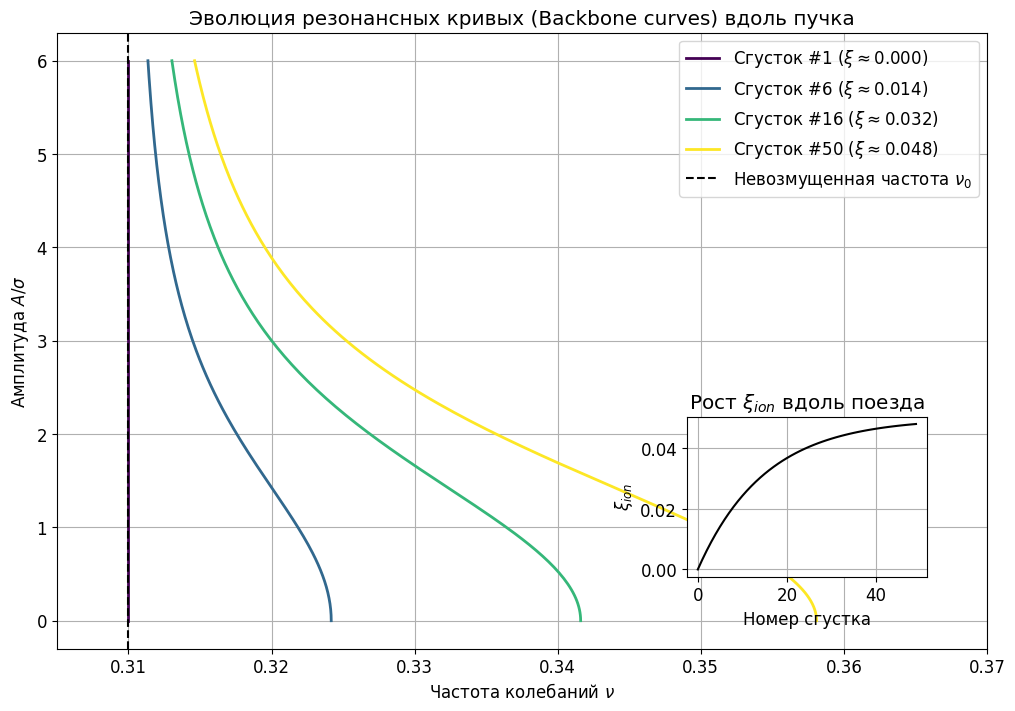

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import i0

# Настройка графиков
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

def tune_shift_factor(amplitude, sigma):
    """
    Форм-фактор сдвига частоты от амплитуды (1D Gaussian).
    Убывает от 1 до 0.
    """
    amp = np.array(amplitude)
    J = (amp**2) / (2 * sigma**2)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        factor = (2.0 / J) * (1.0 - np.exp(-J/2.0) * i0(J/2.0))
    
    factor = np.where(J < 1e-5, 1.0, factor)
    return factor

# Параметры
sigma = 1.0
nu_0 = 0.31
n_bunches = 50 # Количество сгустков в поезде

# Модель накопления ионов (насыщение)
bunch_indices = np.arange(n_bunches)
tau_ion = 15.0 # Характерное время накопления (в сгустках)
xi_max = 0.05  # Максимальный сдвиг частоты (в насыщении)

xi_vals = xi_max * (1 - np.exp(-bunch_indices / tau_ion))

# Амплитуды для построения скелетных кривых
amplitudes = np.linspace(0, 6*sigma, 200)

# Визуализация
plt.figure(figsize=(12, 8))

# Выберем несколько сгустков для отображения
indices_to_plot = [0, 5, 15, 49]
colors = plt.cm.viridis(np.linspace(0, 1, len(indices_to_plot)))

for idx, color in zip(indices_to_plot, colors):
    xi = xi_vals[idx]
    
    # Скелетная кривая: nu(A) = nu_0 + xi * Factor(A)
    # Мы строим A(nu)
    nu_curve = nu_0 + xi * tune_shift_factor(amplitudes, sigma)
    
    label = f'Сгусток #{idx+1} ($\\xi \\approx {xi:.3f}$)'
    plt.plot(nu_curve, amplitudes/sigma, color=color, linewidth=2, label=label)
    
    # "Тень" резонанса (схематично)
    # Просто закрасим область под скелетной кривой для наглядности "наклона"
    # plt.fill_betweenx(amplitudes/sigma, nu_0, nu_curve, color=color, alpha=0.1)

plt.axvline(nu_0, color='black', linestyle='--', label='Невозмущенная частота $\\nu_0$')
plt.title('Эволюция резонансных кривых (Backbone curves) вдоль пучка')
plt.xlabel('Частота колебаний $\\nu$')
plt.ylabel('Амплитуда $A / \sigma$')
plt.legend()
plt.grid(True)
plt.xlim(nu_0 - 0.005, nu_0 + xi_max + 0.01)

# Дополнительный график: рост сдвига частоты вдоль поезда
plt.axes([0.65, 0.2, 0.2, 0.2]) # Вставка
plt.plot(bunch_indices, xi_vals, 'k-')
plt.title('Рост $\\xi_{ion}$ вдоль поезда')
plt.xlabel('Номер сгустка')
plt.ylabel('$\\xi_{ion}$')
plt.grid(True)

plt.show()